In [1]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import torch
from nanodrz.model import DiarizeGPT, Config
from nanodrz.data import libritts_test, artificial_diarisation_sample
from nanodrz.utils import visualise_annotation, play
from nanodrz.download import dl_scp_file

ckpt = torch.load(dl_scp_file("gpudev:/home/harry/storj/runs/nanodrz/1706191922/0007000.pt"))

rsync --partial --progress --human-readable -e ssh gpudev:/home/harry/storj/runs/nanodrz/1706191922/0007000.pt /home/harry/storj/runs/nanodrz/1706191922/0007000.pt
0007000.pt

              0   0%    0.00kB/s    0:00:00  
        582.79M  46%  243.66MB/s    0:00:02  
          1.12G  88%  326.14MB/s    0:00:00  
          1.27G 100%  336.87MB/s    0:00:03 (xfr#1, to-chk=0/1)


In [3]:

config = Config(**ckpt["config"])
model:DiarizeGPT = DiarizeGPT.from_pretrained(ckpt).cuda()

/home/harry/diarisation/.venv/lib/python3.10/site-packages/torch/nn/utils/weight_norm.py:30: UserWarning: torch.nn.utils.weight_norm is deprecated in favor of torch.nn.utils.parametrizations.weight_norm.
  warnings.warn("torch.nn.utils.weight_norm is deprecated in favor of torch.nn.utils.parametrizations.weight_norm.")


25.763375


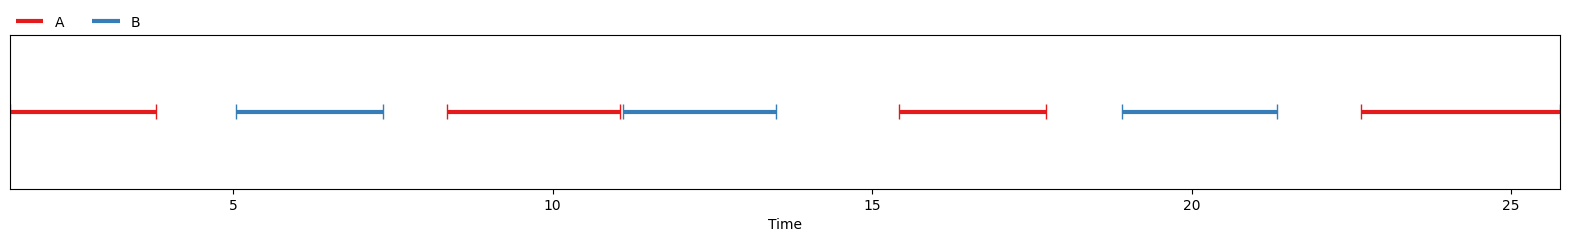

In [4]:
# Use the same parameters that the model was trained on to generate a sample
audio, labels = artificial_diarisation_sample(libritts_test(), **config.data.model_dump())
print(audio.shape[-1]/16000)
reference = visualise_annotation(labels)
play(audio)
labels
audio = audio.cuda()

[5.139442443847656, 7.470119953155518, 'B']
[19.063745498657227, 21.45418357849121, 'A']
[22.828685760498047, 25.876495361328125, 'B']
[8.426295280456543, 11.115538597106934, 'A']
[1.6135458946228027, 3.884462356567383, 'A']
[15.537849426269531, 17.868526458740234, 'A']
[15.537849426269531, 17.868526458740234, 'A']


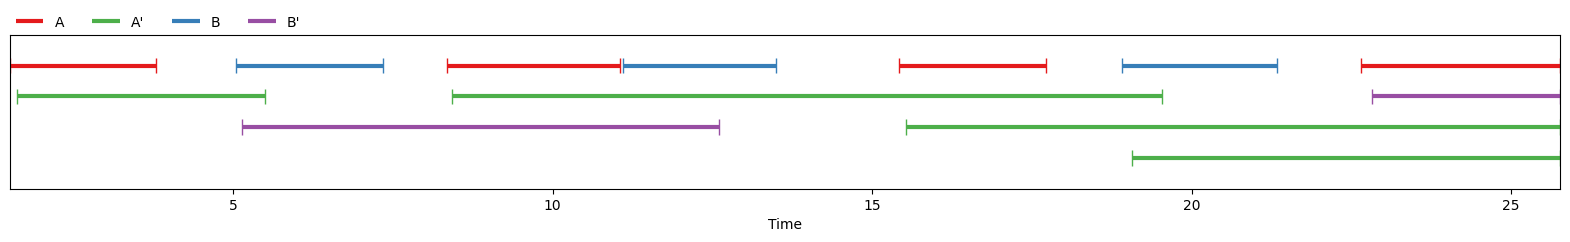

In [6]:
nlabels = model.generate(audio[None], temperature=1, max_steps=(len(labels))*3)
print("\n".join([str(n) for n in nlabels]))
for l in nlabels:
    l[2] = l[2]+ "'"
hypothesis = visualise_annotation(labels+nlabels)

### Calculate Metrics with Pyannote


In [ ]:
from pyannote.core import Annotation
from pyannote.metrics.diarization import DiarizationErrorRate

metric = DiarizationErrorRate()
metric(reference, hypothesis)